In [2]:
import numpy as np
import pandas as pd
# import geopandas as gpd
import os

In [3]:
def load_preprocessed_insitu_data(
    file_list: list[str],
    path_prefix: str = "../data/insitu_data/",
) -> pd.DataFrame:
    """
    Load preprocessed in situ data from CSV files, extract metadata from filenames,
    and concatenate all datasets into a single DataFrame.

    Filenames must follow one of these conventions:

    - ``region_site_version_daily.csv`` : interpolated daily data
    - ``region_site_version.csv`` : site-level, non-interpolated data
    - ``region_version.csv`` : region-level data without a site identifier

    Metadata are parsed from each filename and added as columns to the loaded
    table:

    - ``region`` (str)
    - ``site`` (str | None)
    - ``version`` (str)
    - ``is_interpolated`` (bool)

    In situ data were preprocessed and harmonized to daily values at 12:00 UTC
    by Dagmar Mueller [dagmar.mueller AT brockmann-consult.de] and are available
    in the aquatime-rnd and heatwise-rnd repositories in the most recent versions.

    Timestamps in the preprocessed data are expected to be timezone-aware and
    assigned to UTC for consistency across datasets. If the input index is
    timezone-naive, it is localized to UTC and stored in the column
    ``datetime_utc``.

    Parameters
    ----------
    file_list : list[str]
        Filenames of the CSV files to load.

    path_prefix : str, default "../data/insitu_data/"
        Directory containing the in situ CSV files.

    Returns
    -------
    pd.DataFrame
        Concatenated DataFrame containing the contents of all successfully parsed
        CSV files, augmented with metadata columns:

        - ``region`` : str
        - ``site`` : str | None
        - ``version`` : str
        - ``is_interpolated`` : bool
        - ``datetime_utc`` : pandas.Datetime64[ns, UTC], if created from a
          timezone-naive index

        The original DataFrame index is reset in the final output because
        timestamps alone are not unique across datasets.

    Raises
    ------
    ValueError
        If a filename does not match one of the expected naming conventions.

    Notes
    -----
    Only files ending with ``.csv`` are processed.
    """
    df_list = []

    for f in file_list:
        if not f.endswith(".csv"):
            continue

        stem = f.removesuffix(".csv")
        parts = stem.split("_")

        # region_site_version_daily.csv
        if len(parts) == 4 and parts[-1] == "daily":
            region, site, version, _ = parts
            is_interpolated = True

        # region_site_version.csv
        elif len(parts) == 3:
            region, site, version = parts
            is_interpolated = False

        # region_version.csv
        elif len(parts) == 2:
            region, version = parts
            site = None
            is_interpolated = False

        else:
            raise ValueError(
                f"Filename '{f}' does not match an expected pattern: "
                "'region_site_version_daily.csv', "
                "'region_site_version.csv', or "
                "'region_version.csv'."
            )

        df = pd.read_csv(path_prefix + f, index_col=0, parse_dates=True)
        df["region"] = region
        df["site"] = site
        df["version"] = version
        df["is_interpolated"] = is_interpolated

        # Ensure a consistent UTC timestamp column for downstream merging/analysis.
        dt_index = pd.to_datetime(df.index)

        if getattr(dt_index, "tz", None) is None:
            df["datetime_utc"] = dt_index.tz_localize("UTC")
        else:
            df["datetime_utc"] = dt_index.tz_convert("UTC")

        df_list.append(df)

    if not df_list:
        return pd.DataFrame()

    # Timestamp alone is not unique across datasets, so reset to a simple index.
    return pd.concat(df_list, ignore_index=True)

In [4]:
file_list = os.listdir("../data/insitu_data")

insitu_data = load_preprocessed_insitu_data(file_list)
insitu_data

,Temp °C,Salinity [PSU],Chlg [µg/l],Cgr [µg/l],Ckie [µg/l],Cbl [µg/l],Cbl2 [µg/l],Ccry [µg/l],Cgold [µg/l],Cdino [µg/l],...,aod865,aod1240,tc_ch4,gtco3,tcwv,region,site,version,is_interpolated,datetime_utc
0,1.662000,5.670000,3.965000,0.005365,3.918013,0.017978,0.0,0.000000,0.000000,0.023644,...,0.072679,0.045231,0.010135,0.005612,24.930054,dalaro,dalaro,v0.3,True,2024-03-27 12:00:00+00:00
1,1.648500,5.660000,2.610000,0.003311,2.445259,0.010414,0.0,0.000000,0.000006,0.151009,...,0.077284,0.046296,0.010135,0.005622,26.036362,dalaro,dalaro,v0.3,True,2024-03-28 12:00:00+00:00
2,1.877000,5.525000,7.330000,0.008787,6.556820,0.025951,0.0,0.000000,0.000033,0.738409,...,0.197002,0.119435,0.010122,0.005613,28.145218,dalaro,dalaro,v0.3,True,2024-03-29 12:00:00+00:00
3,2.282000,5.460000,7.680000,0.008757,6.596557,0.024289,0.0,0.000000,0.000048,1.050350,...,0.142240,0.085005,0.010118,0.005542,30.381866,dalaro,dalaro,v0.3,True,2024-03-30 12:00:00+00:00
4,2.037000,5.560000,9.815000,0.010701,8.132734,0.027882,0.0,0.000000,0.000075,1.643608,...,0.107406,0.062167,0.010106,0.005462,36.103560,dalaro,dalaro,v0.3,True,2024-03-31 12:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12863,15.451186,6.488027,0.903054,0.508443,0.020891,0.079807,0.0,0.006463,0.003225,0.284225,...,0.070462,0.040551,0.010086,0.006672,17.697052,uto,uto,v0.3,True,2022-09-26 12:00:00+00:00
12864,15.317363,6.437597,0.764199,0.383153,0.039667,0.113851,0.0,0.004110,0.002048,0.221371,...,0.161559,0.087603,0.010111,0.006307,20.448578,uto,uto,v0.3,True,2022-09-27 12:00:00+00:00
12865,15.085859,6.406653,0.629200,0.295373,0.003655,0.112790,0.0,0.005767,0.001247,0.210368,...,0.010067,0.005680,0.010127,0.006519,12.727120,uto,uto,v0.3,True,2022-09-28 12:00:00+00:00
12866,14.760311,6.313663,0.645834,0.354985,0.022357,0.081924,0.0,0.006455,0.000977,0.179136,...,0.066853,0.035141,0.010139,0.006701,15.271043,uto,uto,v0.3,True,2022-09-29 12:00:00+00:00


In [5]:
def load_preprocessed_calvalus_extracts(
    file_list: list[str],
    path_prefix: str = "../data/eo_data/",
) -> pd.DataFrame:
    """
    Load preprocessed Calvalus extract files, attach metadata derived from
    filenames, and concatenate them into a single pandas DataFrame.

    The input files are expected to be CSV files containing satellite pixel
    extracts generated within the Calvalus processing environment.

    Preprocessed Calvalus extracts were provided by:
    - Jorrit Scholze (jorrit.scholze AT brockmann-consult.de)
    - Petra Philipson (petra.philipson AT brockmann-geomatics.se)

    and further processed by Marcel König (marcel.koenig AT brockmann-consult.de)
    within the *aquatime-rnd* project repository.

    The column ``pixel_time`` in the Calvalus extracts represents the satellite
    observation time and is expected to be in **UTC**. This function converts the
    column to a timezone-aware datetime column ``datetime_utc``.

    Parameters
    ----------
    file_list : list[str]
        Filenames of the CSV files to load.

    path_prefix : str, default "../data/eo_data/"
        Directory containing the Calvalus extract CSV files.

    Returns
    -------
    pd.DataFrame
        Concatenated DataFrame containing all Calvalus extracts with the
        following additional columns:

        - ``region`` : str  
          Region identifier extracted from the filename (assumed to be the
          first underscore-separated token).

        - ``datetime_utc`` : pandas.Datetime64[ns, UTC]  
          Timestamp derived from the ``pixel_time`` column converted to
          a timezone-aware UTC datetime.

        The original DataFrame index from each file is discarded because
        timestamps alone are not unique across datasets. The returned
        DataFrame therefore uses a simple integer index.

    Notes
    -----
    Only files ending with ``calvalus.csv`` are processed.

    The region identifier is inferred from the filename using the pattern:

    ``region_*_calvalus.csv``

    where the first token before the underscore is interpreted as the region.
    """
    df_list = []

    for f in file_list:
        if not f.endswith("calvalus.csv"):
            continue

        region = f.split("_")[0]

        df = pd.read_csv(path_prefix + f, index_col=0)

        df["region"] = region

        # Convert pixel_time to timezone-aware UTC datetime
        df["datetime_utc"] = pd.to_datetime(
            df["pixel_time"], errors="coerce", utc=True
        )

        df_list.append(df)

    if not df_list:
        return pd.DataFrame()

    # Timestamp alone is not unique across datasets → reset index
    return pd.concat(df_list, ignore_index=True)

In [6]:
file_list = os.listdir("../data/eo_data/")

calvalus_data = load_preprocessed_calvalus_extracts(file_list)    
calvalus_data

,CALVALUS_ID,site,Lat,Lon,source_name,pixel_time,pixel_x,pixel_y,pixel_lat,pixel_lon,...,quality_flags.bright,quality_flags.straylight_risk,quality_flags.invalid,quality_flags.cosmetic,quality_flags.duplicated,quality_flags.sun_glint_risk,quality_flags.dubious,mph_chl_flags.mph_cyano,mph_chl_flags.mph_floating,mph_chl_flags.mph_adjacency
0,000002_S2A_MSIL1C_20150704T101006_N0500_R022_T...,dalaro,59.126910,18.466644,S2A_MSIL1C_20150704T101006_N0500_R022_T33VXF_2...,2015-07-04 10:10:06+00:00,1639.000000,677.000000,59.127029,18.466551,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000002_S2A_MSIL1C_20150724T101006_N0500_R022_T...,dalaro,59.126910,18.466644,S2A_MSIL1C_20150724T101006_N0500_R022_T33VXF_2...,2015-07-24 10:10:06+00:00,1639.000000,677.000000,59.127029,18.466551,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000002_S2A_MSIL1C_20150803T101016_N0500_R022_T...,dalaro,59.126910,18.466644,S2A_MSIL1C_20150803T101016_N0500_R022_T33VXF_2...,2015-08-03 10:10:16+00:00,1639.333333,677.333333,59.126841,18.466882,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,000002_S2A_MSIL1C_20150806T102016_N0500_R065_T...,dalaro,59.126910,18.466644,S2A_MSIL1C_20150806T102016_N0500_R065_T33VXF_2...,2015-08-06 10:20:16+00:00,1639.000000,677.000000,59.127029,18.466551,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,000002_S2A_MSIL1C_20150810T100016_N0500_R122_T...,dalaro,59.126910,18.466644,S2A_MSIL1C_20150810T100016_N0500_R122_T33VXF_2...,2015-08-10 10:00:16+00:00,1639.000000,677.000000,59.127029,18.466551,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8301,000003_S3B_OL_1_EFR____20251010T095015_2025101...,sodra bergundasjon,56.845105,14.782672,S3B_OL_1_EFR____20251010T095015_20251010T09531...,2025-10-10 09:51:32+00:00,3414.666667,1767.666667,56.845527,14.783227,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.333333
8302,000003_S3B_OL_1_EFR____20251011T092404_2025101...,sodra bergundasjon,56.845105,14.782672,S3B_OL_1_EFR____20251011T092404_20251011T09270...,2025-10-11 09:25:36+00:00,1982.875000,2108.875000,56.847266,14.780779,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.125000
8303,000003_S3B_OL_1_EFR____20251013T101242_2025101...,sodra bergundasjon,56.845105,14.782672,S3B_OL_1_EFR____20251013T101242_20251013T10154...,2025-10-13 10:13:42+00:00,4610.000000,1379.500000,56.846256,14.780808,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1.000000
8304,000003_S3B_OL_1_EFR____20251018T094247_2025101...,sodra bergundasjon,56.845105,14.782672,S3B_OL_1_EFR____20251018T094247_20251018T09454...,2025-10-18 09:44:09+00:00,3008.666667,1877.666667,56.846396,14.781850,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.000000


In [7]:
import pandas as pd


def _to_utc_ts(x) -> pd.Timestamp:
    """
    Convert a datetime-like input to a timezone-aware UTC pandas Timestamp.

    Parameters
    ----------
    x : str | datetime-like | pd.Timestamp
        Input value that can be parsed by ``pandas.Timestamp``.

    Returns
    -------
    pd.Timestamp
        Timezone-aware timestamp with timezone ``UTC``.

    Notes
    -----
    If `x` is timezone-naive, it is localized to UTC.
    If `x` is already timezone-aware, it is converted to UTC.
    """
    ts = pd.Timestamp(x)
    if ts.tzinfo is None:
        return ts.tz_localize("UTC")
    return ts.tz_convert("UTC")


def subset_calvalus_extracts(
    df: pd.DataFrame,
    columns: list[str],
    sites: list[str] | None = None,
    regions: list[str] | None = None,
    systems: list[str] | None = None,
    datetime_min=None,
    datetime_max=None,
    datetime_col: str = "datetime_utc",
    site_col: str = "site",
    region_col: str = "region",
    system_col: str = "system",
) -> pd.DataFrame:
    """
    Subset a Calvalus extract DataFrame using strict validation for region, site,
    system, and time constraints.

    This function applies a consistent filtering workflow with explicit checks:

    - requested `regions` must exist in the DataFrame
    - requested `systems` must exist in the DataFrame
    - requested `sites` must exist in the DataFrame
    - requested `sites` must belong to the requested `regions`
    - requested `systems` must occur within the selected
      region/site/time subset
    - if only `regions` are provided and `sites` is omitted, all sites within
      those regions are automatically included

    The returned DataFrame contains only the requested data columns plus the
    key columns used for downstream identification and merging.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing Calvalus extracts and metadata columns.

    columns : list[str]
        Names of the data columns to keep in the output in addition to the
        key columns.

    sites : list[str] | None, default None
        Site identifiers to include.

        - dtype of values: `str`
        - if `None` or empty, no site filter is applied
        - if `regions` is given and `sites` is `None`, all sites within the
          selected regions are used automatically

    regions : list[str] | None, default None
        Region identifiers to include.

        - dtype of values: `str`
        - if `None` or empty, no region filter is applied

    systems : list[str] | None, default None
        Sensor or processing system identifiers to include.

        - dtype of values: `str`
        - if `None` or empty, no system filter is applied

    datetime_min : str | datetime-like | pd.Timestamp | None, default None
        Inclusive lower time bound.

        - converted internally to `pd.Timestamp`
        - resulting dtype: `pandas.Timestamp` with timezone `UTC`

    datetime_max : str | datetime-like | pd.Timestamp | None, default None
        Inclusive upper time bound.

        - converted internally to `pd.Timestamp`
        - resulting dtype: `pandas.Timestamp` with timezone `UTC`

    datetime_col : str, default "datetime_utc"
        Name of the datetime column to use for temporal filtering.

        - expected dtype: `datetime64[ns, UTC]`

        If this column is not present, the DataFrame index is used instead and
        must be timezone-aware.

    site_col : str, default "site"
        Name of the site column.

        - expected dtype: `object` / string-like

    region_col : str, default "region"
        Name of the region column.

        - expected dtype: `object` / string-like

    system_col : str, default "system"
        Name of the system column.

        - expected dtype: `object` / string-like

    Returns
    -------
    pd.DataFrame
        Filtered DataFrame containing:

        - all requested rows matching the validated selection criteria
        - the key columns
          (`site_col`, `region_col`, `system_col`, `datetime_col`)
        - the requested `columns`

        The output includes only columns that actually exist in the filtered
        DataFrame.

    Raises
    ------
    ValueError
        If one or more of the following conditions occur:

        - `datetime_col` or the DatetimeIndex is timezone-naive
        - requested regions are not found in the DataFrame
        - requested systems are not found in the DataFrame
        - requested sites are not found in the DataFrame
        - requested sites are not located in the requested regions
        - requested systems do not occur within the selected
          region/site/time subset

    Notes
    -----
    Time filtering is inclusive on both bounds:

    - `datetime_min` → `>=`
    - `datetime_max` → `<=`

    Duplicate column names are avoided in the output while preserving order.
    """
    # ---- normalize inputs: None or [] means "no filter" ----
    regions = list(regions) if regions else None
    sites = list(sites) if sites else None
    systems = list(systems) if systems else None

    # ---- time bounds ----
    dt_min = _to_utc_ts(datetime_min) if datetime_min is not None else None
    dt_max = _to_utc_ts(datetime_max) if datetime_max is not None else None

    # ---- datetime handling ----
    if datetime_col in df.columns:
        dt = df[datetime_col]
        if getattr(dt.dt, "tz", None) is None:
            raise ValueError(f"'{datetime_col}' must be tz-aware (UTC).")
    else:
        dt = df.index
        if getattr(dt, "tz", None) is None:
            raise ValueError(
                "Datetime index must be tz-aware (UTC) or provide a datetime column."
            )

    # ---- strict validation: regions (global existence) ----
    if regions is not None:
        existing_regions = set(df[region_col].dropna().unique())
        unknown_regions = [r for r in regions if r not in existing_regions]
        if unknown_regions:
            raise ValueError(f"Regions not found in DataFrame: {unknown_regions}")

    # ---- strict validation: systems (global existence) ----
    if systems is not None:
        existing_systems = set(df[system_col].dropna().unique())
        unknown_systems = [s for s in systems if s not in existing_systems]
        if unknown_systems:
            raise ValueError(f"Systems not found in DataFrame: {unknown_systems}")

    # ---- auto-expand sites if only regions provided ----
    if regions is not None and sites is None:
        sites = (
            df.loc[df[region_col].isin(regions), site_col]
            .dropna()
            .unique()
            .tolist()
        )

    # ---- strict validation: sites (global existence) ----
    if sites is not None:
        existing_sites = set(df[site_col].dropna().unique())
        unknown_sites = [s for s in sites if s not in existing_sites]
        if unknown_sites:
            raise ValueError(f"Sites not found in DataFrame: {unknown_sites}")

        # ---- strict validation: site-region consistency ----
        if regions is not None:
            site_region_map = (
                df[[site_col, region_col]]
                .dropna()
                .drop_duplicates()
                .groupby(site_col)[region_col]
                .apply(set)
            )
            invalid_sites = [s for s in sites if site_region_map[s].isdisjoint(regions)]
            if invalid_sites:
                raise ValueError(
                    f"Sites {invalid_sites} are not located in the specified regions {regions}."
                )

    # ---- base mask for region/site/time ----
    base_mask = pd.Series(True, index=df.index)

    if dt_min is not None:
        base_mask &= dt >= dt_min
    if dt_max is not None:
        base_mask &= dt <= dt_max

    if regions is not None:
        base_mask &= df[region_col].isin(regions)
    if sites is not None:
        base_mask &= df[site_col].isin(sites)

    # ---- strict consistency: systems must occur within the base selection ----
    if systems is not None:
        available_systems_in_selection = set(
            df.loc[base_mask, system_col].dropna().unique()
        )
        missing_in_selection = [
            s for s in systems if s not in available_systems_in_selection
        ]
        if missing_in_selection:
            raise ValueError(
                "Requested systems do not occur within the selected region/site/time "
                f"constraints: {missing_in_selection}. Available systems there: "
                f"{sorted(available_systems_in_selection)}"
            )

    # ---- final mask includes systems ----
    mask = base_mask.copy()
    if systems is not None:
        mask &= df[system_col].isin(systems)

    # ---- keep required columns ----
    keep = list(dict.fromkeys([site_col, region_col, system_col, datetime_col, *columns]))

    out = df.loc[mask].copy()
    if datetime_col not in out.columns:
        out[datetime_col] = out.index

    keep_existing = [c for c in keep if c in out.columns]
    return out[keep_existing]

In [8]:
col_list = [
    'iop_apig',
    'iop_adet',
    'iop_agelb',
    'iop_bpart',
    'iop_bwit',
    'iop_adg',
    'iop_atot',
    'iop_btot',
    'conc_chl',
    'tur_665',
    'tur_865',
    'secchi_depth',
    'immersed_cyanobacteria',
    'immersed_cyanobacteria_class',
    'net'
]

calvalus_sub = subset_calvalus_extracts(
    calvalus_data,
    columns=col_list,
    systems=["S2","S3"],
    sites=None, #["hohenwutzen", "bunthaus", "seemannshoeft", "frankfurt", "sodra bergundasjon"],
    regions=None,
    datetime_min="2015-01-01",
    datetime_max="2025-01-01",
)

calvalus_sub

,site,region,system,datetime_utc,iop_apig,iop_adet,iop_agelb,iop_bpart,iop_bwit,iop_adg,iop_atot,iop_btot,conc_chl,tur_665,tur_865,secchi_depth,immersed_cyanobacteria,immersed_cyanobacteria_class,net
0,dalaro,dalaro,S2,2015-07-04 10:10:06+00:00,0.096321,0.208761,0.108362,1.718473,1.221885,0.317123,0.413444,2.940358,1.856401,3.644960,1.425072,2.092883,NaN,NaN,NaN
1,dalaro,dalaro,S2,2015-07-24 10:10:06+00:00,0.082932,0.128499,0.556388,0.917553,0.954929,0.684887,0.767819,1.872482,1.599422,2.463418,0.955758,2.862054,NaN,NaN,NaN
2,dalaro,dalaro,S2,2015-08-03 10:10:16+00:00,0.145879,0.057825,0.940855,0.398829,0.294674,0.998680,1.144559,0.693503,2.975793,1.103524,0.335322,4.982460,NaN,NaN,NaN
3,dalaro,dalaro,S2,2015-08-06 10:20:16+00:00,0.128655,0.073600,1.147064,0.513672,0.661201,1.220665,1.349319,1.174872,2.515409,1.707410,0.611828,3.448699,NaN,NaN,NaN
4,dalaro,dalaro,S2,2015-08-10 10:00:16+00:00,0.125895,0.294380,0.151680,1.643291,1.692496,0.446060,0.571955,3.335787,2.437095,3.864612,1.710717,1.629320,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8191,sodra bergundasjon,sodra-bergundasjon,S3,2024-10-06 09:17:57+00:00,0.614040,3.341068,0.486281,0.122367,5.056621,3.827349,4.441389,5.178988,12.758595,NaN,NaN,NaN,0.000000,NaN,NaN
8192,sodra bergundasjon,sodra-bergundasjon,S3,2024-10-17 09:32:50+00:00,0.657068,1.198789,0.238315,0.593644,6.071869,1.437104,2.094172,6.665513,13.592744,NaN,NaN,NaN,0.000000,NaN,NaN
8193,sodra bergundasjon,sodra-bergundasjon,S3,2024-10-23 10:17:11+00:00,0.459253,0.917780,0.118403,0.011739,6.065517,1.036184,1.495437,6.077256,9.350234,NaN,NaN,NaN,0.000000,NaN,NaN
8194,sodra bergundasjon,sodra-bergundasjon,S3,2024-10-25 09:25:25+00:00,0.642846,1.163605,0.149734,0.210772,4.550737,1.313339,1.956184,4.761509,13.265993,NaN,NaN,NaN,0.000000,NaN,NaN


In [9]:
def load_syke_extracts(
    file_list: list[str],
    path_prefix: str = "../data/eo_data/",
) -> pd.DataFrame:
    """
    Load preprocessed SYKE EO statistics extracts, reshape them to wide format,
    and attach metadata derived from the filenames and source fields.

    The input files are expected to be CSV files containing Earth Observation
    statistics computed for predefined regions within Lake Pyhäjärvi. These
    statistics summarize satellite-derived water quality variables over the
    spatial extent of the region.

    Preprocessed EO extracts were provided by Sakari Väkevä
    (sakari.vakeva AT syke.fi) and further processed by Marcel König
    (marcel.koenig AT brockmann-consult.de) within the *aquatime-rnd*
    project repository.

    Input EO statistics format
    --------------------------
    The statistics are split by:

    - **variable** (e.g., chlorophyll, turbidity)
    - **region** (lake-wide or reference stations)
    - **source system** (satellite/instrument)

    The ``SourceSystem`` column encodes information about the origin of the data:

    Example values::

        EO_HR_WQ_LC8
        EO_HR_WQ_S2
        EO_MR_WQ_SST

    The naming convention indicates:

    - ``EO`` : Earth Observation data source
    - ``HR`` or ``MR`` : spatial resolution class (High Resolution or Medium Resolution)
    - ``WQ`` : water quality product
    - sensor/instrument identifier

    Typical instruments include:

    - Sentinel-2 MSI
    - Landsat-8/9 OLI/TIRS
    - Sentinel-3 SLSTR (for SST products)

    Regions
    -------
    The statistics are computed for three sub-areas of Lake Pyhäjärvi,
    identified by the ``RegionID`` column:

    - ``6396-34.031.1.001_001``
        Reference station No. 6396 (Pyhäjärvi 93 va93)
        Latitude: 61.0255, Longitude: 22.2052

    - ``82751-34.031.1.001_001``
        Reference station No. 82751 (automatic measurement station)
        Latitude: 60.9145, Longitude: 22.3762

    - ``34.031.1.001_001``
        Entire lake water body (excluding shallow areas)

    These identifiers are mapped to simplified site names using an internal
    lookup table.

    Input file columns
    ------------------
    The SYKE EO statistics files typically contain the following columns:

    - ``SourceSystem`` : identifier of satellite system and processing chain
    - ``Parameter`` : variable name (`chl`, `cdom`, `sdt`, `turb`, or `sst`)
    - ``RegionType`` : region classification
      (`RFS2018`, `REF_STATION`, `VPD2LAKE`, `VPD4LAKE`)
    - ``RegionID`` : identifier of the lake region
    - ``Date`` : date for which the EO statistics are valid
    - ``flag`` : quality flag (`ok` or `uncertain`)
    - ``geomean`` : geometric mean of valid pixels
    - ``mean`` : arithmetic mean of valid pixels
    - ``p05``, ``p25``, ``median``, ``p75``, ``p95`` : distribution percentiles
    - ``samplesize`` : number of valid EO pixels used in the estimate

    In this function:

    - rows are filtered to ``flag == "ok"``
    - the ``median`` statistic is used
    - data are pivoted so each ``Parameter`` becomes a separate column

    Timestamp handling
    ------------------
    The SYKE statistics contain only a date (``Date`` column) without a
    time-of-day component.

    The function constructs a timezone-aware timestamp column
    ``datetime_utc``:

    - time is set to ``00:00:00``
    - timezone is assigned as ``UTC``

    Parameters
    ----------
    file_list : list[str]
        Filenames of the CSV files to load.

        dtype of values: `str`

    path_prefix : str, default "../data/eo_data/"
        Directory containing the SYKE extract CSV files.

    Returns
    -------
    pd.DataFrame
        Concatenated DataFrame containing all processed SYKE extracts with
        the following additional columns:

        ``region`` : str
            Region identifier derived from the filename (first token before "_").

        ``datetime_utc`` : pandas.Datetime64[ns, UTC]
            Timestamp derived from the ``Date`` column.

        ``system`` : str | NaN
            Harmonized sensor identifier derived from ``SourceSystem``.

        ``site`` : str | NaN
            Simplified site identifier mapped from ``RegionID``.

        The output also includes the pivot index columns:

        - ``SourceSystem``
        - ``RegionType``
        - ``RegionID``

        and one column per EO parameter (e.g., ``chl``, ``turb``, ``sst``)
        containing the ``median`` value.

        The returned DataFrame uses a simple integer index.

    Raises
    ------
    KeyError
        If required columns are missing from an input file.

    ValueError
        If no matching ``*syke.csv`` files are found or if no valid rows remain
        after filtering.

    Notes
    -----
    Only files ending with ``"syke.csv"`` are processed.

    Filenames are expected to follow the pattern::

        region_*_syke.csv

    where the first underscore-separated token corresponds to the region name.

    Rows with ``flag != "ok"`` are discarded.
    """
    
    SYSTEMS = {
        "EO_HR_WQ_LC8": "LC8",
        "EO_HR_WQ_S2": "S2",
        "EO_MR_WQ_SST": "SLSTR",
        "EO_SAMPI_S2_MSI": "S2",
    }

    SITES = {
        "6396-34.031.1.001_001": "6396",
        "82751-34.031.1.001_001": "82751",
        "34.031.1.001_001": "entire lake",
    }

    df_list = []

    required_cols = {
        "Date",
        "flag",
        "median",
        "Parameter",
        "SourceSystem",
        "RegionType",
        "RegionID",
    }

    for f in file_list:
        if not f.endswith("syke.csv"):
            continue

        region = f.split("_")[0]

        df = pd.read_csv(path_prefix + f, index_col=0)

        missing_cols = required_cols.difference(df.columns)
        if missing_cols:
            raise KeyError(
                f"File '{f}' is missing required columns: {sorted(missing_cols)}"
            )

        df["datetime_utc"] = pd.to_datetime(df["Date"], errors="coerce").dt.tz_localize(
            "UTC"
        )

        df_out = pd.pivot_table(
            df[df["flag"] == "ok"],
            values="median",
            columns="Parameter",
            index=["SourceSystem", "RegionType", "RegionID", "datetime_utc"],
        ).reset_index()

        df_out["region"] = region
        df_out["system"] = df_out["SourceSystem"].map(SYSTEMS)
        df_out["site"] = df_out["RegionID"].map(SITES)

        df_list.append(df_out)

    if not df_list:
        raise ValueError("No files ending with 'syke.csv' were found in file_list.")

    out = pd.concat(df_list, ignore_index=True)

    if out.empty:
        raise ValueError("No valid SYKE extract data remained after processing.")

    return out

In [10]:
pyha = load_syke_extracts(file_list)

In [11]:
# Mapping dicts for column name harmonization between SYKE and Calvalus datasets.
# SYKE uses short parameter names; Calvalus uses longer, more descriptive names.
# The convention adopted here is the Calvalus naming.

SYKE_TO_CALVALUS: dict[str, str] = {
    "chla": "conc_chl",
    "turb": "tur_865",
    "sdt": "secchi_depth",
    "cdom": "iop_agelb",
    # "sst" has no Calvalus equivalent and is kept as-is
}

# Extend this dict if any Calvalus column needs to be renamed to a common name.
CALVALUS_RENAME: dict[str, str] = {}


def rename_eo_columns(df: pd.DataFrame, mapping: dict[str, str]) -> pd.DataFrame:
    """
    Rename columns in a DataFrame according to a mapping dictionary.

    Columns not present in ``mapping`` are left unchanged. This function is
    used to harmonize column names between the SYKE and Calvalus EO datasets
    so that shared variables (e.g. chlorophyll, turbidity, Secchi depth) carry
    identical names in both DataFrames.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame whose columns should be renamed.

    mapping : dict[str, str]
        Dictionary mapping old column names to new column names.
        Example: ``{"chla": "conc_chl", "turb": "tur_865"}``

    Returns
    -------
    pd.DataFrame
        DataFrame with columns renamed according to ``mapping``.
        The original DataFrame is not modified.
    """
    return df.rename(columns=mapping)

In [12]:
# Net-selection configuration for Calvalus sites where the same observation was
# processed with multiple algorithms (nets).  Each key is a (site, system) tuple.
# ``param_nets`` maps individual column names to the net whose value should be used.
# ``default_net`` is the fallback for all columns not listed in ``param_nets``.

NET_CONFIG: dict[tuple[str, str], dict] = {
    ("malaren", "S2"): {
        "param_nets": {
            "iop_adg": "c2rcc",
            "conc_chl": "complex",
            "tur_865": "complex",
            "secchi_depth": "complex",
        },
        "default_net": "complex",
    },
    ("sodra bergundasjon", "S2"): {
        "param_nets": {
            "conc_chl": "c2x",
            "tur_865": "complex",
            "secchi_depth": "complex",
        },
        "default_net": "complex",
    },
}


def resolve_calvalus_nets(
    df: pd.DataFrame,
    net_config: dict[tuple[str, str], dict],
    net_col: str = "net",
    site_col: str = "site",
    system_col: str = "system",
    datetime_col: str = "datetime_utc",
) -> pd.DataFrame:
    """
    Resolve multi-net duplicates in a Calvalus extract DataFrame.

    For some sites and sensor systems the same satellite observation is
    processed with multiple algorithms (nets), resulting in several rows that
    share the same ``(site, system, datetime_utc)`` key but differ only in the
    ``net`` column and the derived water quality parameters.  This function
    merges those duplicate rows into a single row by selecting, for each
    column, the value from the net specified in ``net_config``.

    Rows belonging to sites / systems that are **not** listed in
    ``net_config``, or rows where ``net`` is NaN (single-net observations),
    are returned unchanged.

    Parameters
    ----------
    df : pd.DataFrame
        Calvalus extract DataFrame, typically the output of
        :func:`subset_calvalus_extracts`.  Must contain the columns
        ``site_col``, ``system_col``, and ``datetime_col``.

    net_config : dict[tuple[str, str], dict]
        Mapping from ``(site, system)`` tuples to net-selection rules.
        Each rule is a dict with two keys:

        - ``"param_nets"`` : dict[str, str]
            Maps column names to the net whose value should be used for
            that column.  Example: ``{"conc_chl": "complex"}``.

        - ``"default_net"`` : str
            Fallback net used for all columns **not** listed in
            ``"param_nets"``.

        Example::

            {
                ("malaren", "S2"): {
                    "param_nets": {
                        "iop_adg":      "c2rcc",
                        "conc_chl":     "complex",
                        "tur_865":      "complex",
                        "secchi_depth": "complex",
                    },
                    "default_net": "complex",
                },
            }

    net_col : str, default ``"net"``
        Name of the column that identifies the processing net.

    site_col : str, default ``"site"``
        Name of the site column.

    system_col : str, default ``"system"``
        Name of the sensor system column (e.g. ``"S2"``, ``"S3"``).

    datetime_col : str, default ``"datetime_utc"``
        Name of the UTC datetime column used to identify individual
        observations.

    Returns
    -------
    pd.DataFrame
        DataFrame with the same columns as the input but with multi-net
        duplicates merged into single rows.  The index is reset.  The
        ``net_col`` column in merged rows contains the ``default_net`` value
        for that (site, system) pair (reflecting which net was used for the
        majority of columns).

    Notes
    -----
    - For a group where the desired net for a column is absent, the value is
      set to NaN.
    - Non-parameter columns (key columns and any column not covered by
      ``param_nets`` or ``default_net``) are taken from the ``default_net``
      row; if that row is missing they are taken from the first available row.
    - Sites / systems without a ``net_config`` entry are passed through
      untouched, even if they happen to contain duplicate rows for other
      reasons.
    """
    key_cols = [site_col, system_col, datetime_col]
    configured_keys = set(net_config.keys())

    # Mask for rows that belong to a configured (site, system) pair
    configured_mask = df.apply(
        lambda row: (row.get(site_col), row.get(system_col)) in configured_keys,
        axis=1,
    )

    passthrough = df[~configured_mask].copy()
    configured_df = df[configured_mask].copy()

    merged_rows: list[pd.Series] = []

    for (site, system), config in net_config.items():
        param_nets: dict[str, str] = config["param_nets"]
        default_net: str = config["default_net"]

        subset = configured_df[
            (configured_df[site_col] == site) & (configured_df[system_col] == system)
        ]
        if subset.empty:
            continue

        for _, group in subset.groupby(datetime_col, sort=False):
            if len(group) == 1:
                # Single row — no merging needed
                merged_rows.append(group.iloc[0])
                continue

            # Build a mapping from net name → row (Series) for this group
            net_rows: dict[str, pd.Series] = {
                row[net_col]: row for _, row in group.iterrows()
                if pd.notna(row.get(net_col))
            }

            # Start with the default_net row as the base; fall back to first row
            base_row = net_rows.get(default_net, group.iloc[0]).copy()

            # Override individual columns with the net specified in param_nets
            for col in group.columns:
                if col in key_cols or col == net_col:
                    continue
                desired_net = param_nets.get(col, default_net)
                if desired_net in net_rows:
                    base_row[col] = net_rows[desired_net][col]
                else:
                    base_row[col] = float("nan")

            merged_rows.append(base_row)

    if not merged_rows:
        return pd.concat([passthrough], ignore_index=True)

    merged_df = pd.DataFrame(merged_rows)
    return pd.concat([passthrough, merged_df], ignore_index=True)

In [13]:
# Resolve multi-net duplicates in the Calvalus data
calvalus_resolved = resolve_calvalus_nets(calvalus_sub, NET_CONFIG)

# Harmonize SYKE column names to match Calvalus naming convention
syke_harmonized = rename_eo_columns(pyha, SYKE_TO_CALVALUS)

print(f"Calvalus rows before: {len(calvalus_sub):>6}  after: {len(calvalus_resolved)}")
print(f"SYKE columns renamed: { {k: v for k, v in SYKE_TO_CALVALUS.items() if k in pyha.columns} }")
display(calvalus_resolved.head())
display(syke_harmonized.head())

Calvalus rows before:   7645  after: 7358
SYKE columns renamed: {'chla': 'conc_chl', 'turb': 'tur_865', 'sdt': 'secchi_depth', 'cdom': 'iop_agelb'}


,site,region,system,datetime_utc,iop_apig,iop_adet,iop_agelb,iop_bpart,iop_bwit,iop_adg,iop_atot,iop_btot,conc_chl,tur_665,tur_865,secchi_depth,immersed_cyanobacteria,immersed_cyanobacteria_class,net
0,dalaro,dalaro,S2,2015-07-04 10:10:06+00:00,0.096321,0.208761,0.108362,1.718473,1.221885,0.317123,0.413444,2.940358,1.856401,3.644960,1.425072,2.092883,NaN,NaN,NaN
1,dalaro,dalaro,S2,2015-07-24 10:10:06+00:00,0.082932,0.128499,0.556388,0.917553,0.954929,0.684887,0.767819,1.872482,1.599422,2.463418,0.955758,2.862054,NaN,NaN,NaN
2,dalaro,dalaro,S2,2015-08-03 10:10:16+00:00,0.145879,0.057825,0.940855,0.398829,0.294674,0.998680,1.144559,0.693503,2.975793,1.103524,0.335322,4.982460,NaN,NaN,NaN
3,dalaro,dalaro,S2,2015-08-06 10:20:16+00:00,0.128655,0.073600,1.147064,0.513672,0.661201,1.220665,1.349319,1.174872,2.515409,1.707410,0.611828,3.448699,NaN,NaN,NaN
4,dalaro,dalaro,S2,2015-08-10 10:00:16+00:00,0.125895,0.294380,0.151680,1.643291,1.692496,0.446060,0.571955,3.335787,2.437095,3.864612,1.710717,1.629320,NaN,NaN,NaN


Parameter,SourceSystem,RegionType,RegionID,datetime_utc,iop_agelb,conc_chl,secchi_depth,sst,tur_865,region,system,site
0,EO_HR_WQ_LC8,RFS2019,6396-34.031.1.001_001,2014-07-23 00:00:00+00:00,NaN,NaN,NaN,24.78,NaN,pyhajarvi,LC8,6396
1,EO_HR_WQ_LC8,RFS2019,6396-34.031.1.001_001,2014-09-16 00:00:00+00:00,NaN,NaN,NaN,15.76,NaN,pyhajarvi,LC8,6396
2,EO_HR_WQ_LC8,RFS2019,6396-34.031.1.001_001,2015-05-30 00:00:00+00:00,NaN,NaN,NaN,12.33,NaN,pyhajarvi,LC8,6396
3,EO_HR_WQ_LC8,RFS2019,6396-34.031.1.001_001,2015-07-01 00:00:00+00:00,NaN,NaN,NaN,16.87,NaN,pyhajarvi,LC8,6396
4,EO_HR_WQ_LC8,RFS2019,6396-34.031.1.001_001,2015-08-18 00:00:00+00:00,NaN,NaN,NaN,20.68,NaN,pyhajarvi,LC8,6396


In [14]:
eo_data_harmonized = pd.concat([
    syke_harmonized[['datetime_utc', 'region', 'site', 'system', 'conc_chl', 'tur_865', 'secchi_depth', 'iop_agelb']],  
    calvalus_data[['datetime_utc', 'region', 'site', 'system', 'conc_chl', 'tur_865', 'secchi_depth', 'iop_agelb']]
        ], ignore_index=True)


In [15]:
EO_KEY_COLS = ["conc_chl", "tur_865", "secchi_depth", "iop_agelb"]

# Drop rows where every one of the key columns is NaN (no usable retrieval).
# Rows with at least one non-NaN value among EO_KEY_COLS are kept.
eo_filtered = eo_data_harmonized.dropna(subset=EO_KEY_COLS, how="all").reset_index(drop=True)

print(f"Rows before filter: {len(eo_data_harmonized):>6}")
print(f"Rows after  filter: {len(eo_filtered):>6}  ({len(eo_data_harmonized) - len(eo_filtered)} removed)")
eo_filtered

Rows before filter:  12554
Rows after  filter:   9740  (2814 removed)


,datetime_utc,region,site,system,conc_chl,tur_865,secchi_depth,iop_agelb
0,2020-08-08 00:00:00+00:00,pyhajarvi,6396,LC8,NaN,2.92,1.68,3.650000
1,2021-05-30 00:00:00+00:00,pyhajarvi,6396,LC8,NaN,3.48,1.65,6.370000
2,2021-07-01 00:00:00+00:00,pyhajarvi,6396,LC8,NaN,2.61,2.01,4.430000
3,2021-07-26 00:00:00+00:00,pyhajarvi,6396,LC8,NaN,1.87,4.53,2.320000
4,2022-08-14 00:00:00+00:00,pyhajarvi,6396,LC8,NaN,2.60,2.38,4.010000
...,...,...,...,...,...,...,...,...
9735,2025-10-10 09:51:32+00:00,sodra-bergundasjon,sodra bergundasjon,S3,9.214351,NaN,NaN,0.559933
9736,2025-10-11 09:25:36+00:00,sodra-bergundasjon,sodra bergundasjon,S3,13.654578,NaN,NaN,0.357445
9737,2025-10-13 10:13:42+00:00,sodra-bergundasjon,sodra bergundasjon,S3,2.518962,NaN,NaN,0.857571
9738,2025-10-18 09:44:09+00:00,sodra-bergundasjon,sodra bergundasjon,S3,18.801998,NaN,NaN,0.458045


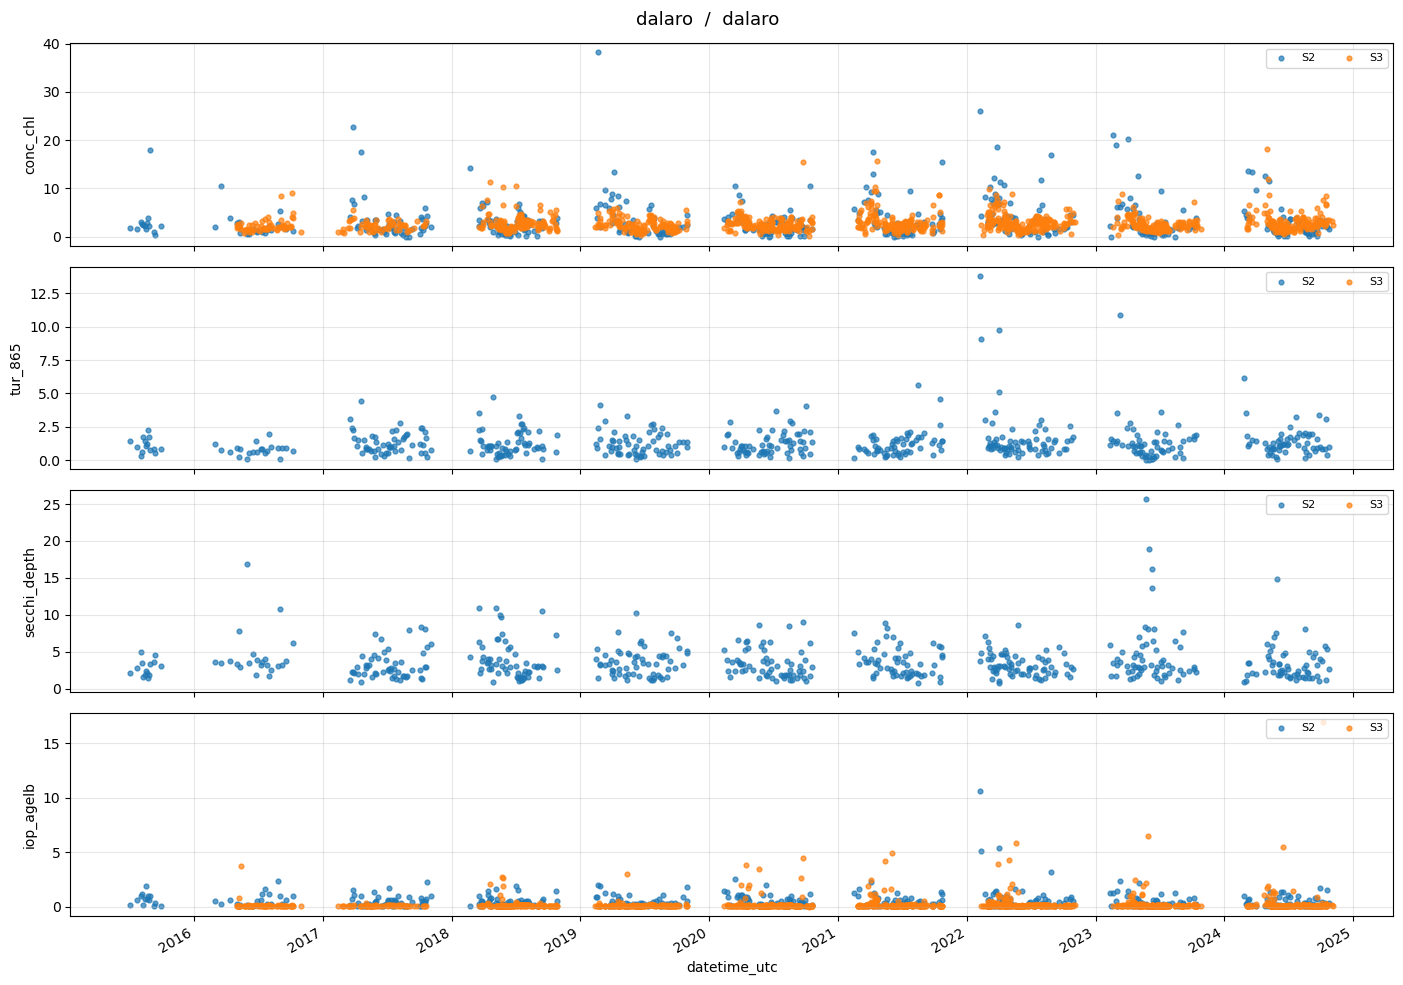

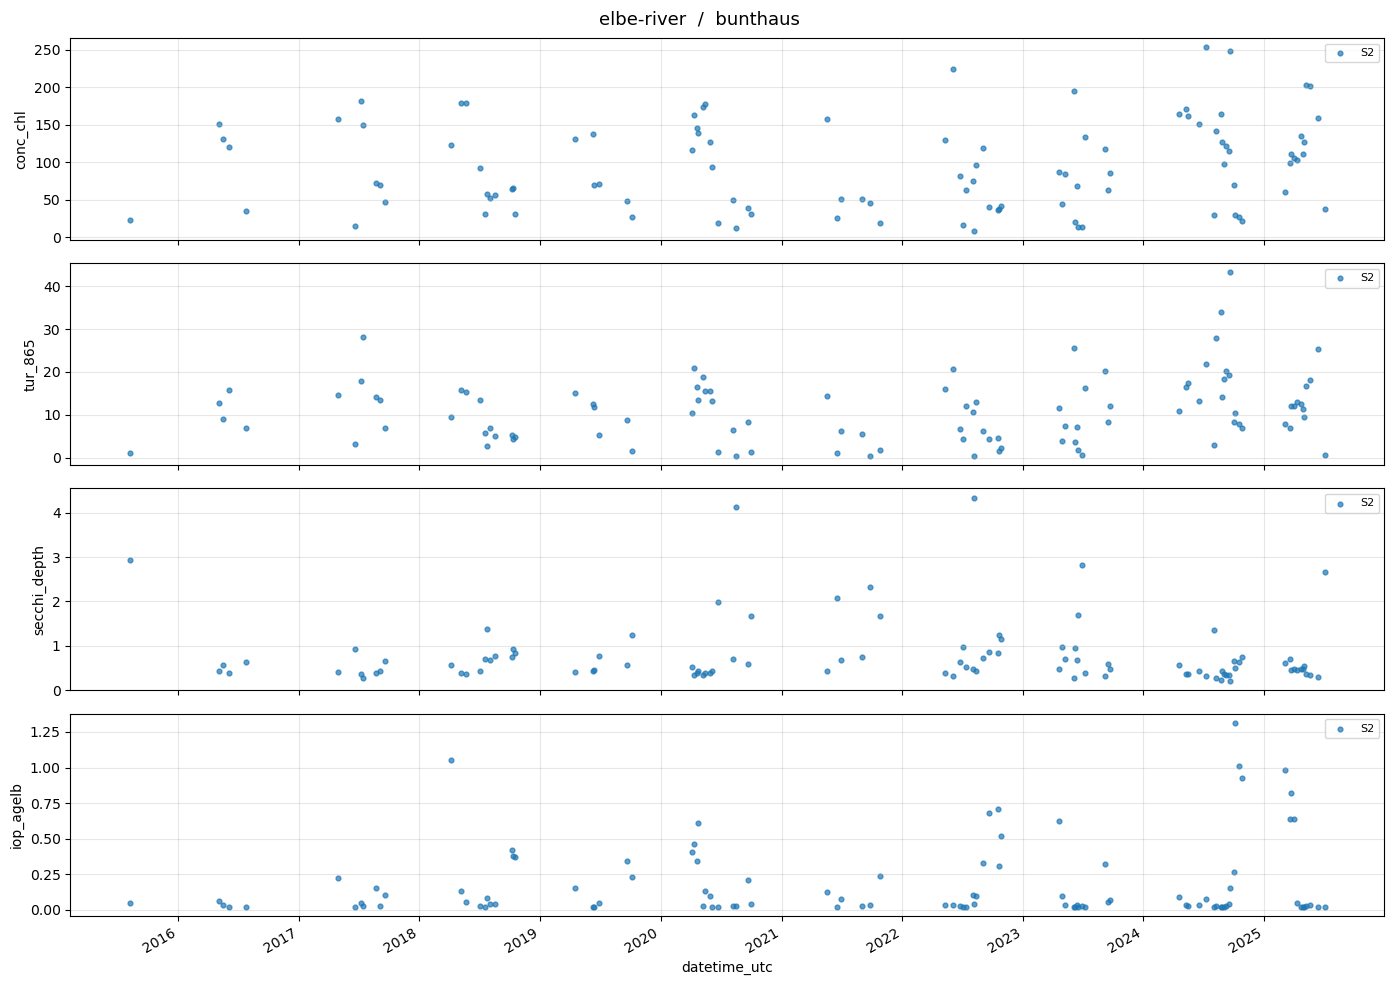

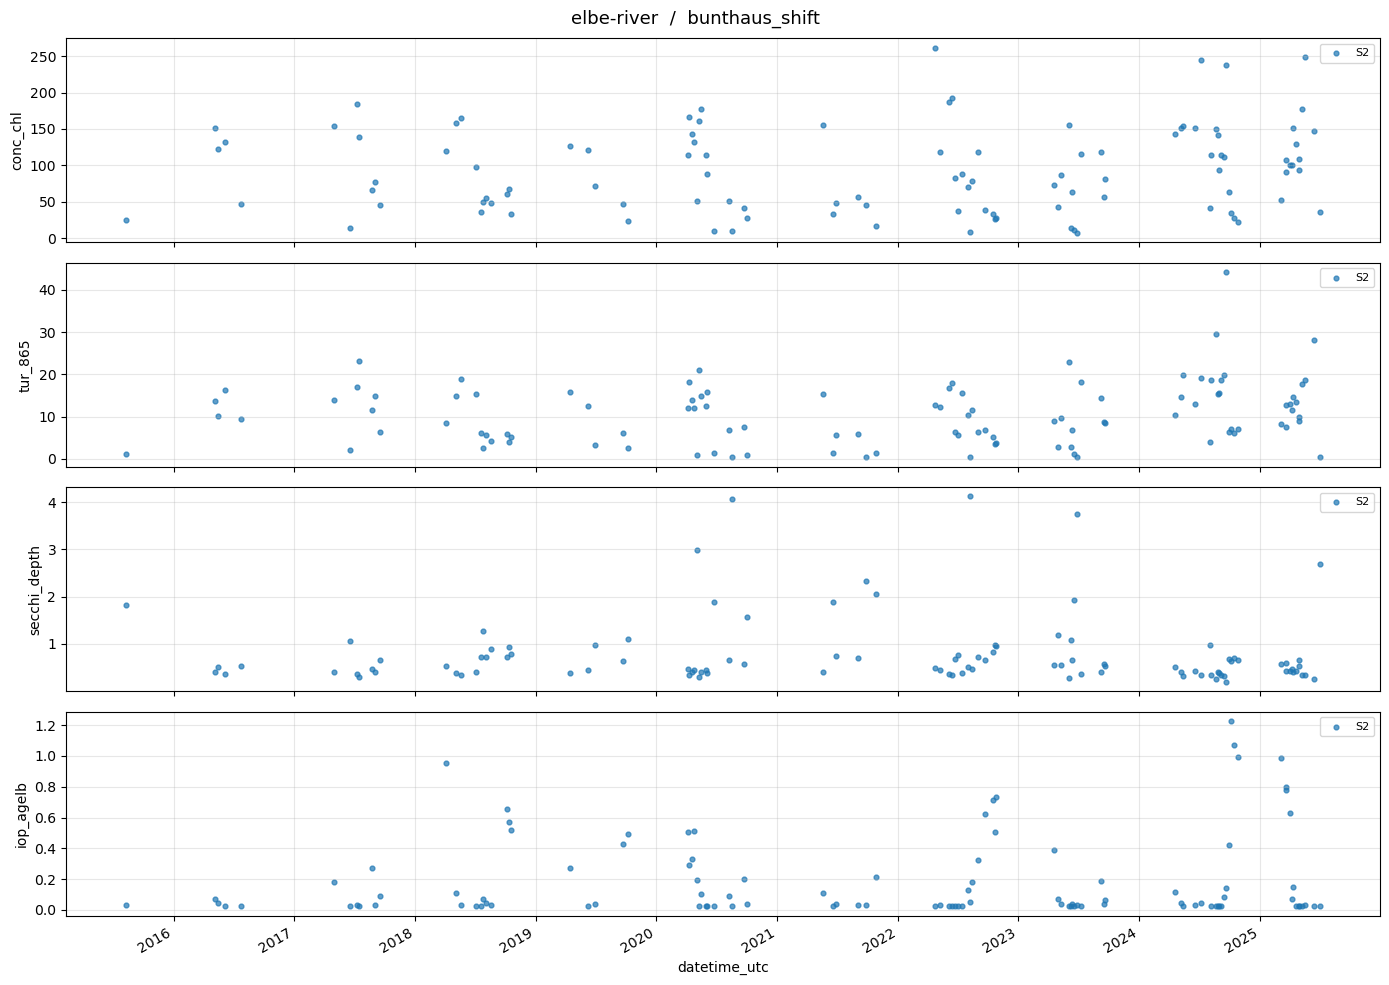

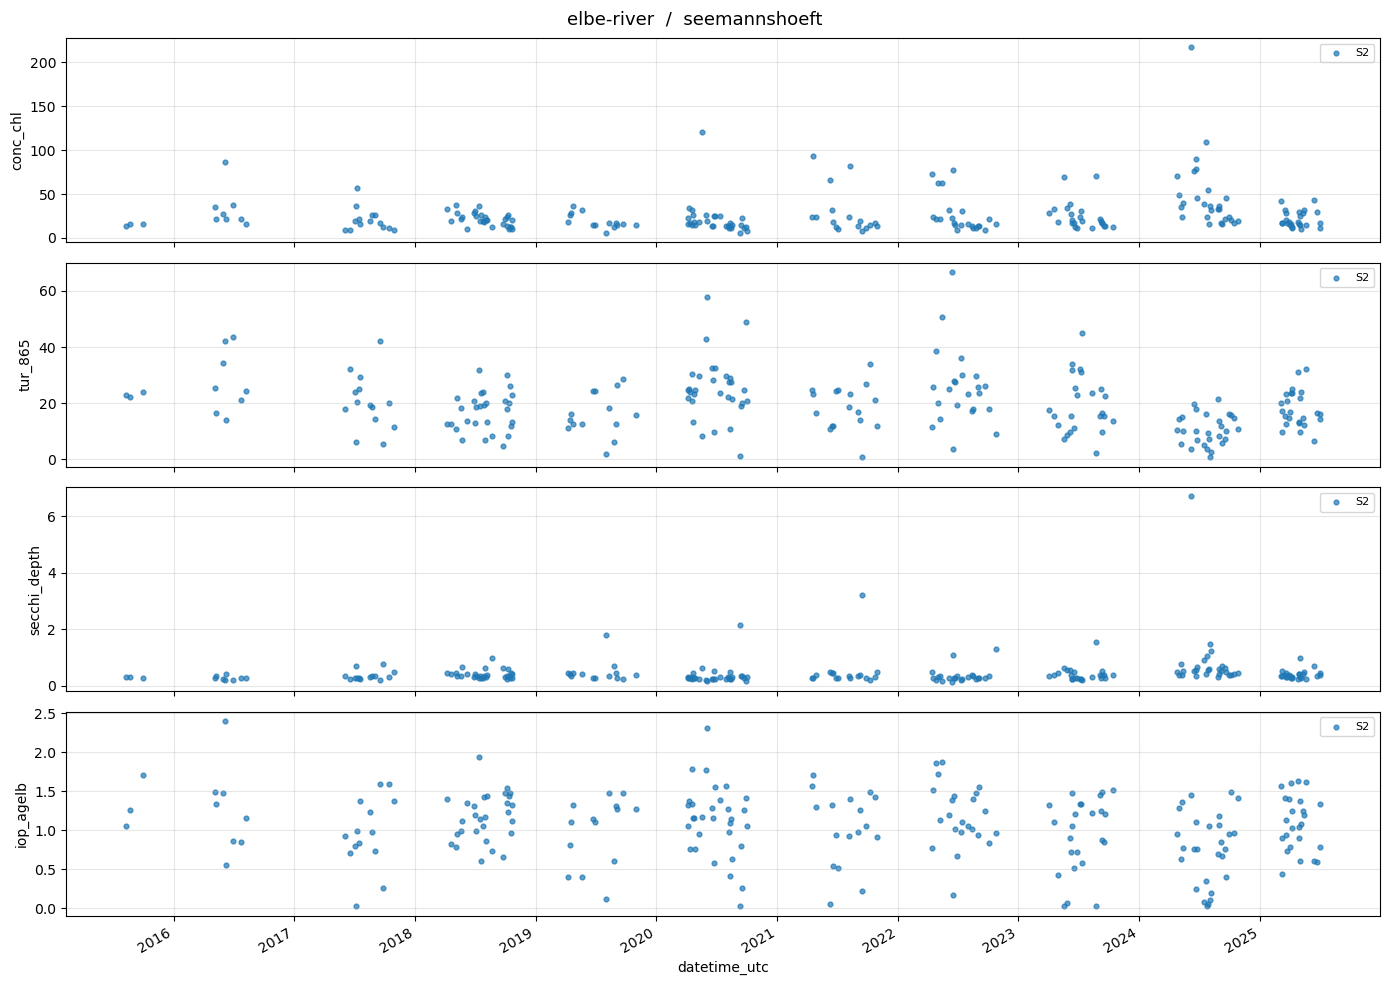

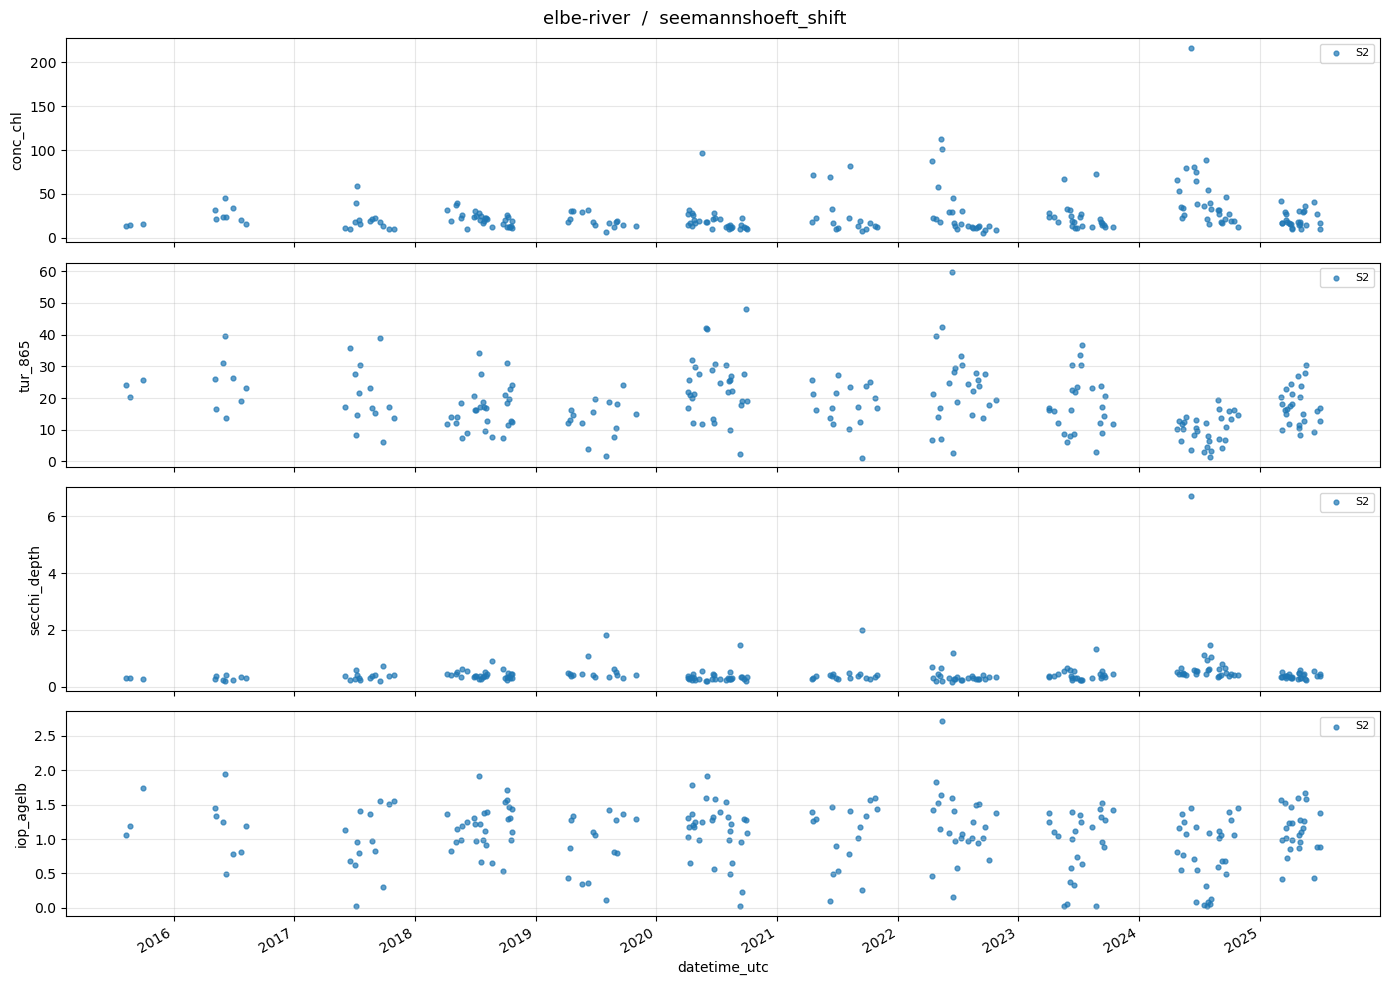

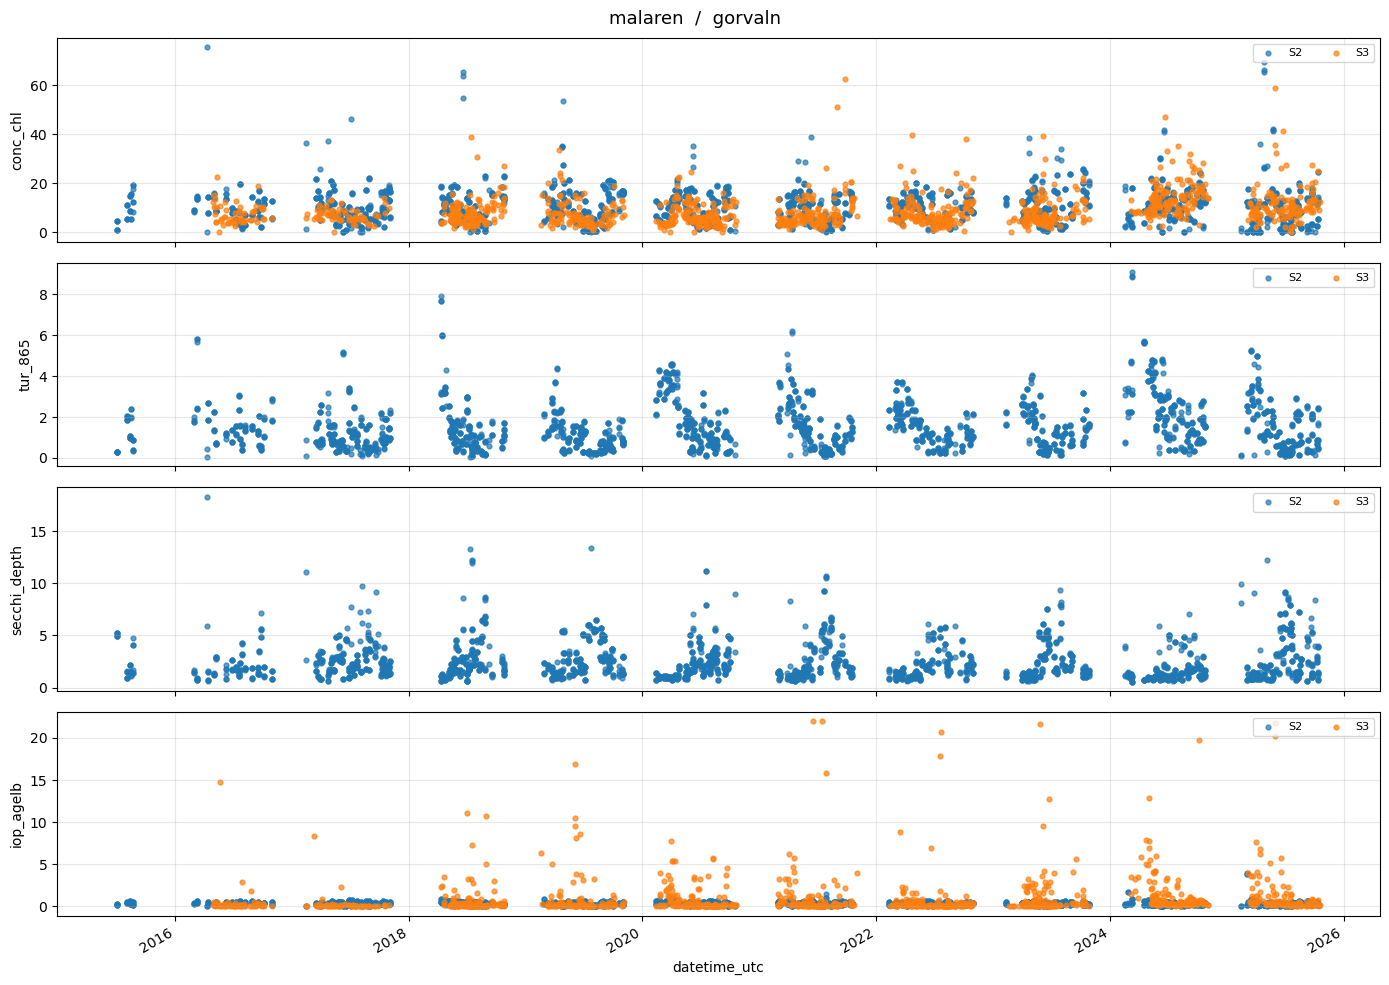

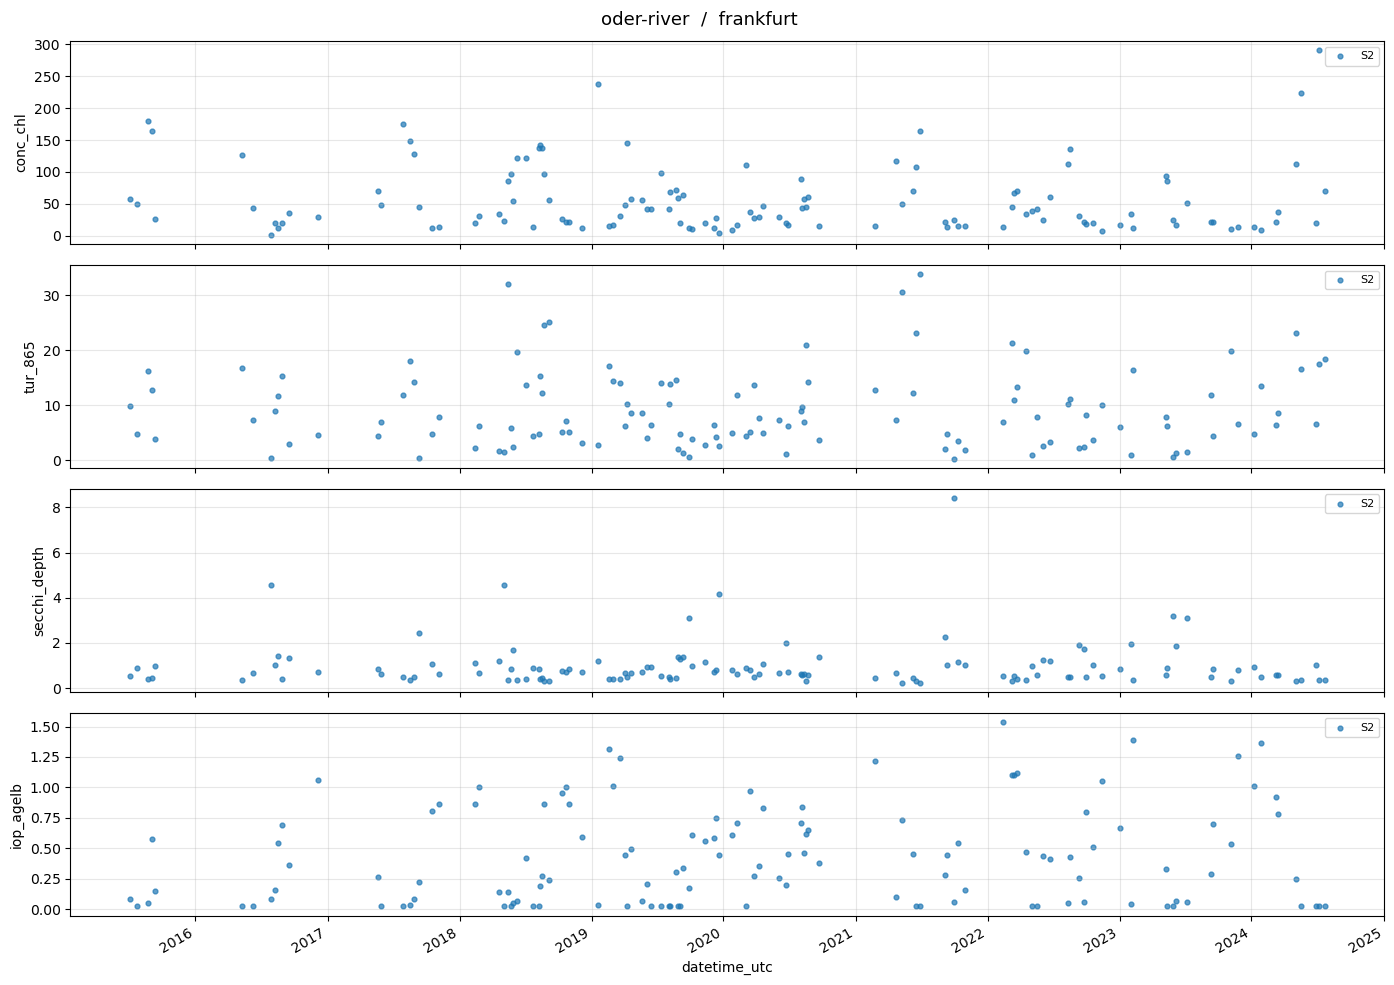

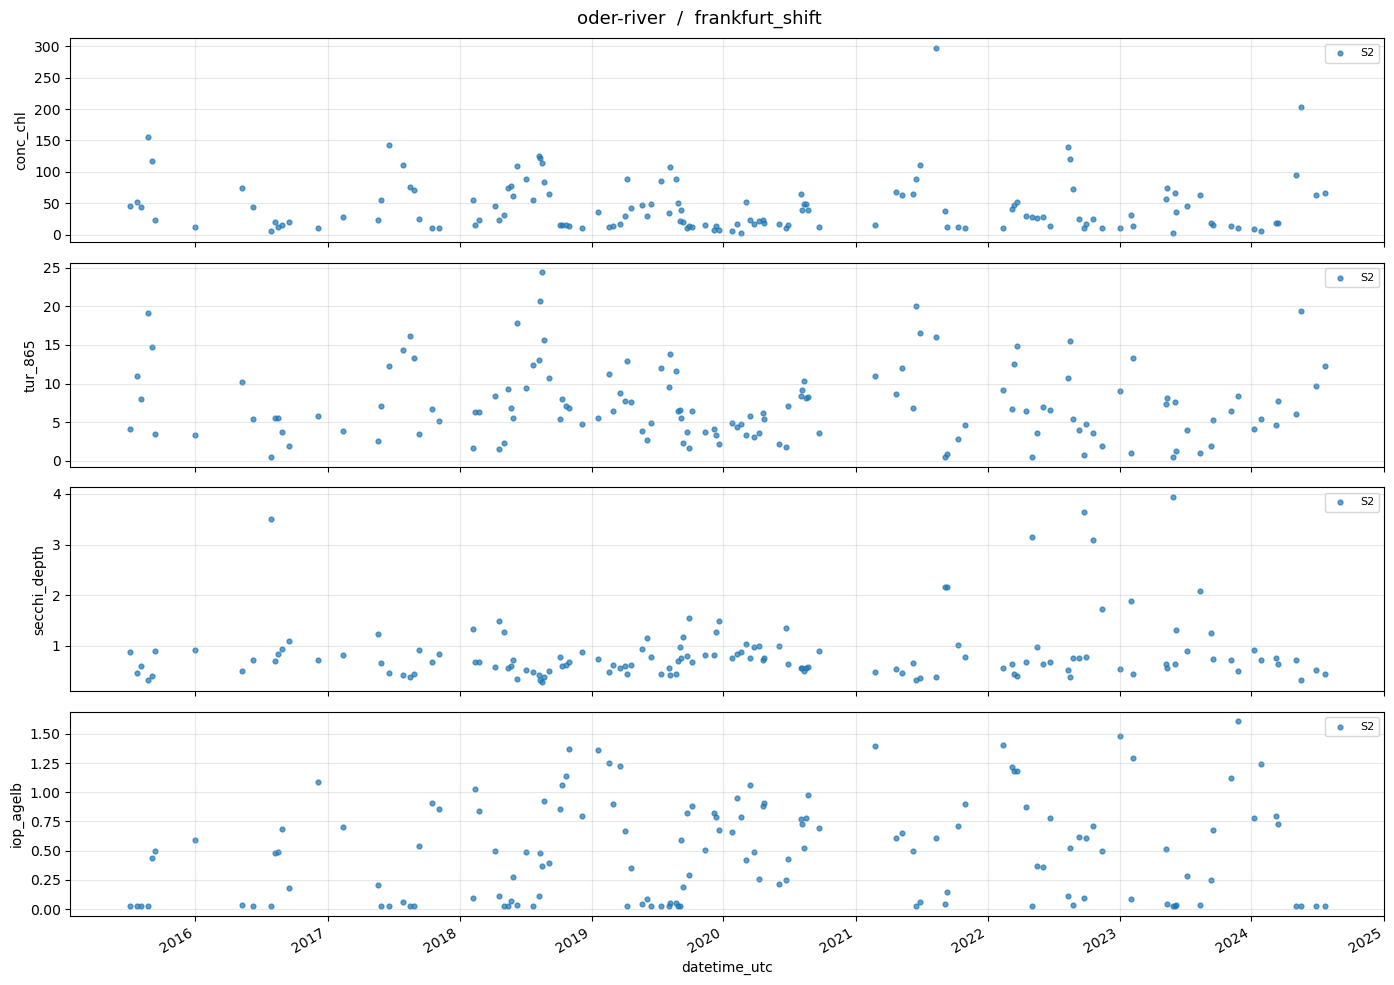

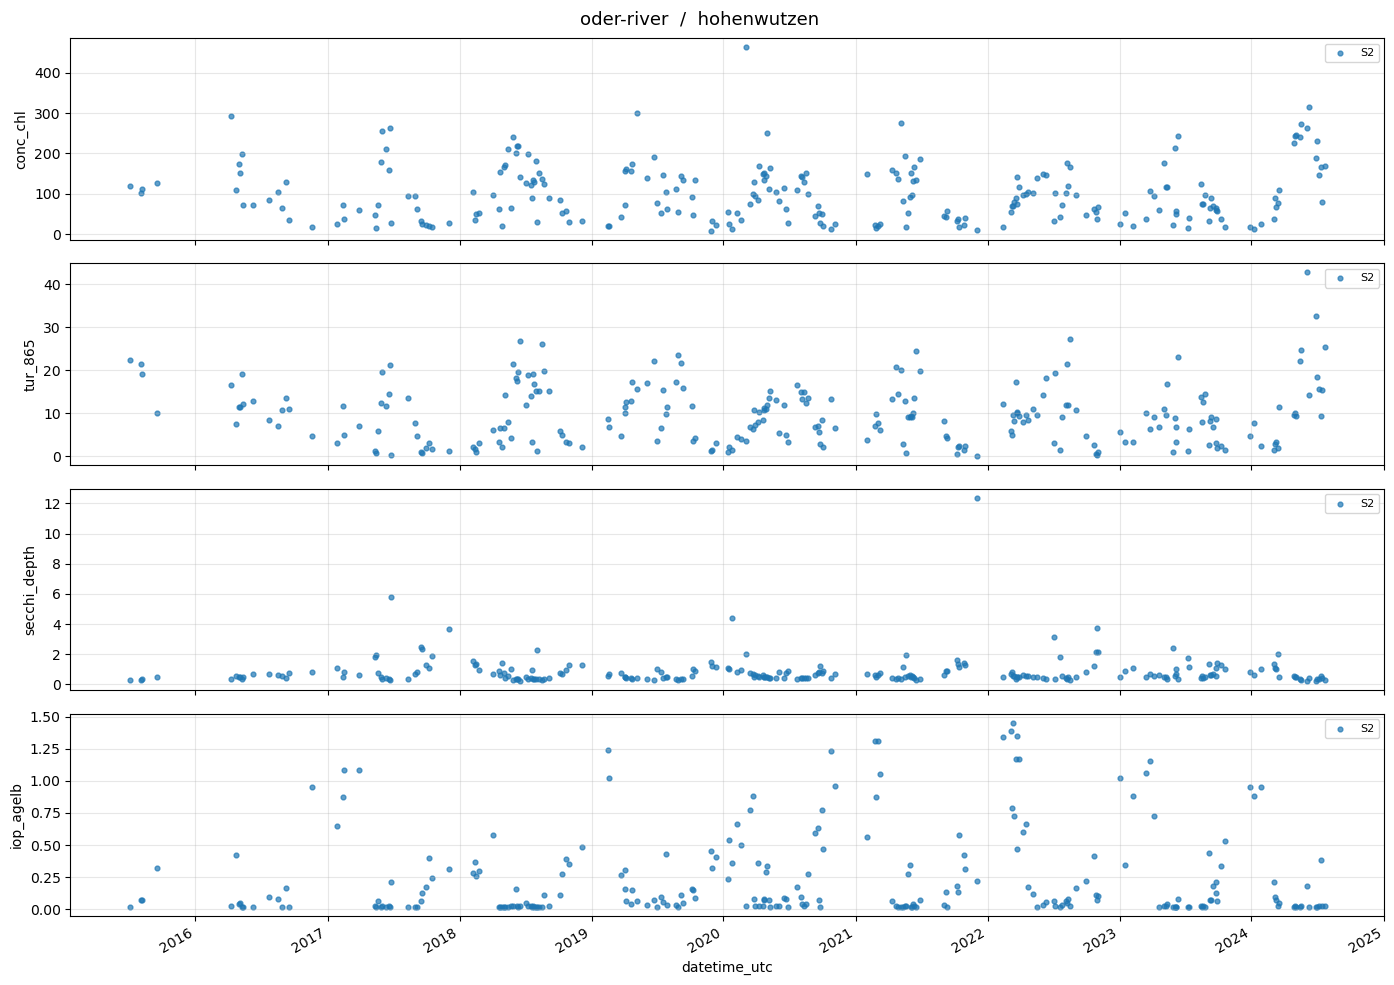

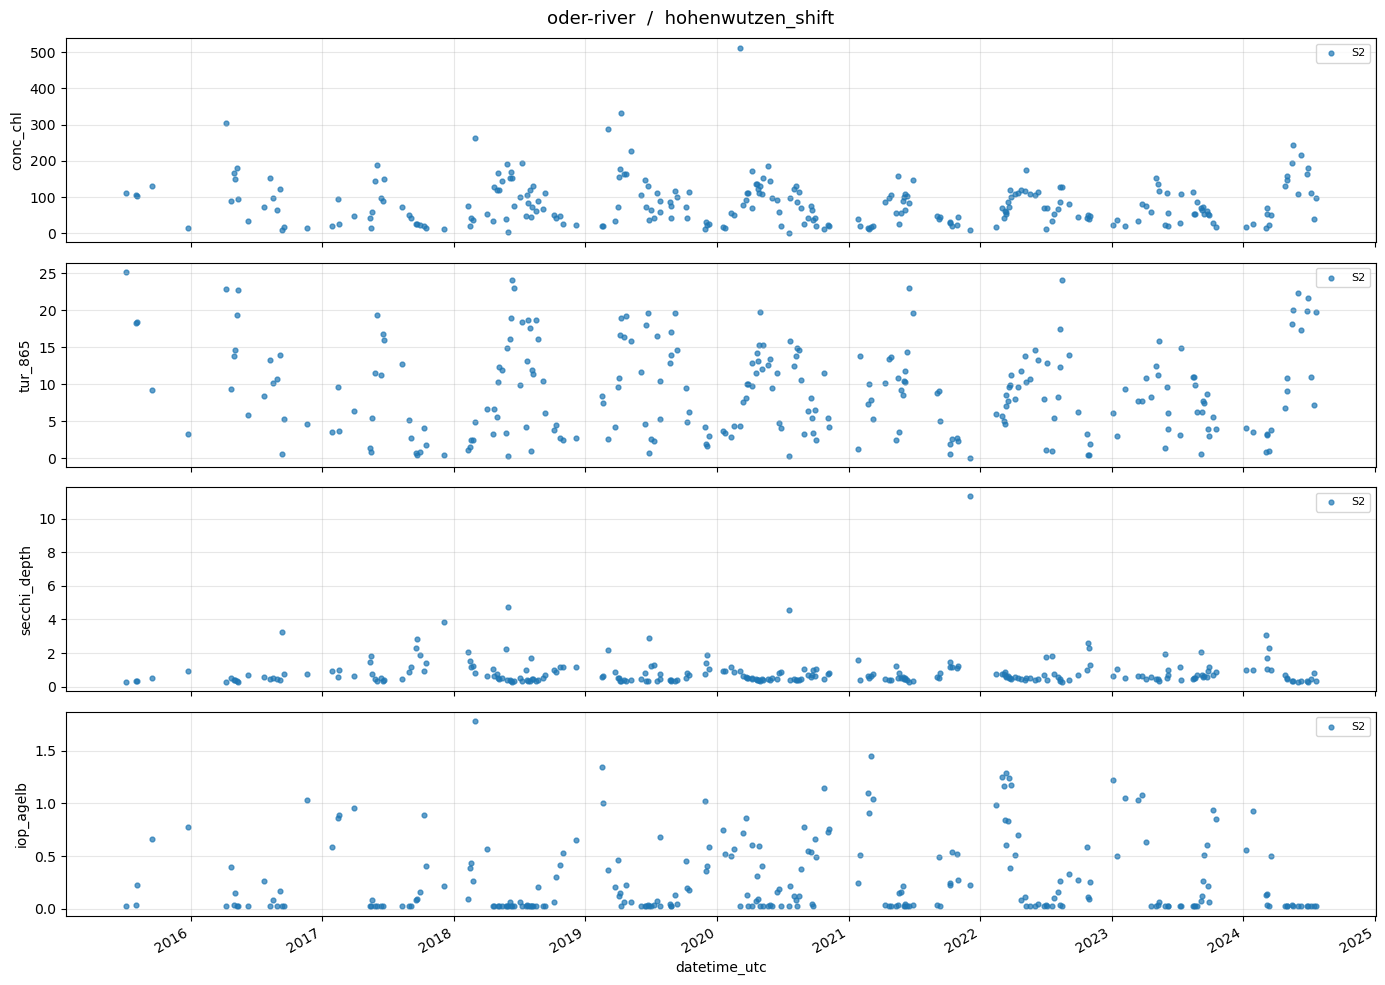

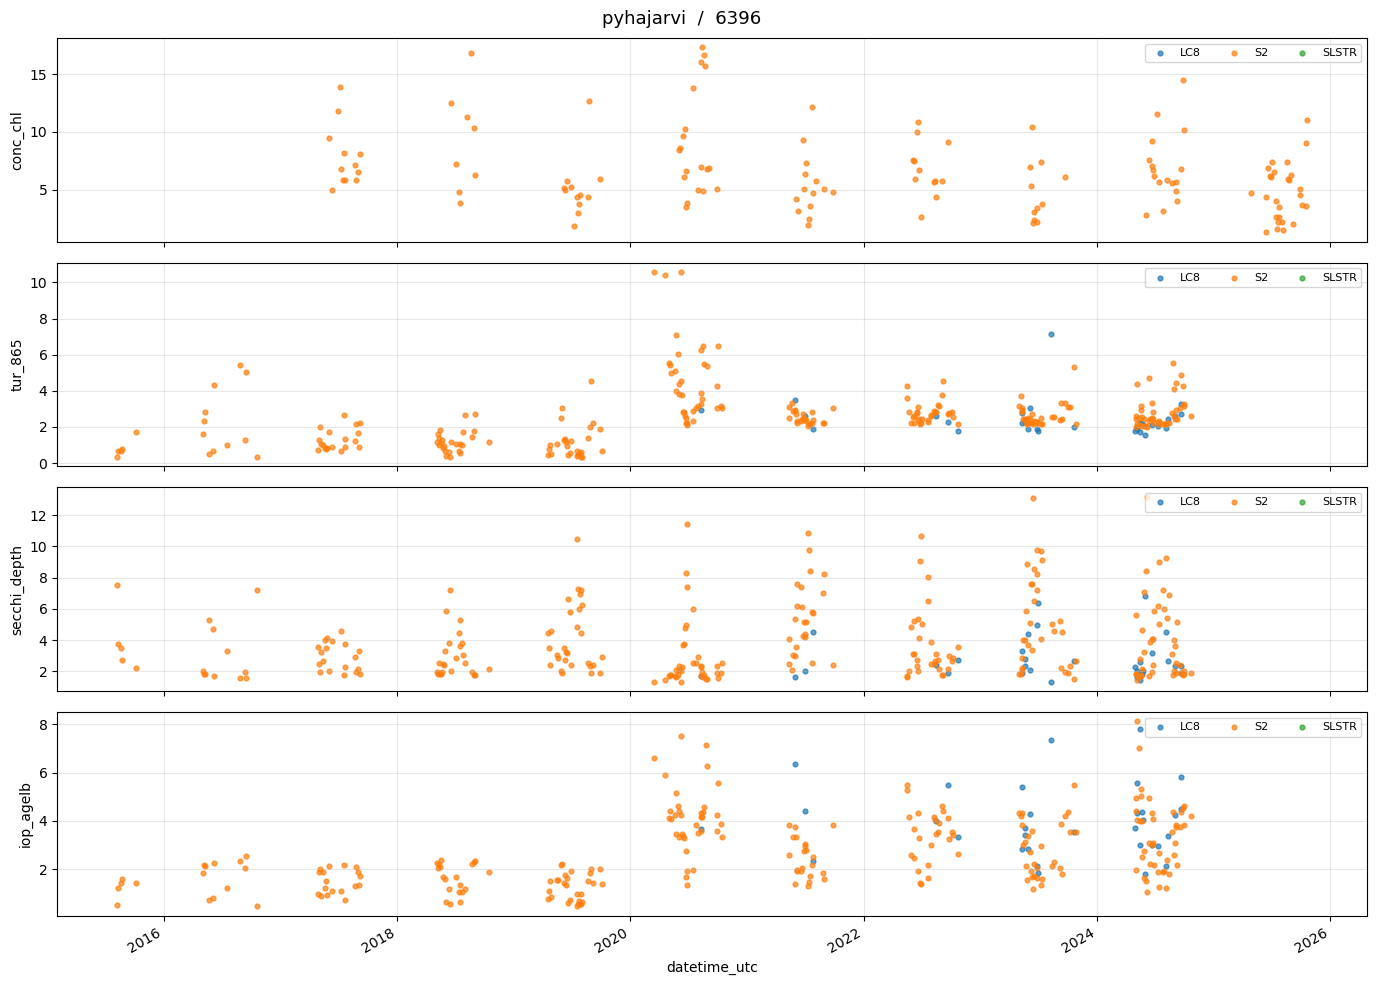

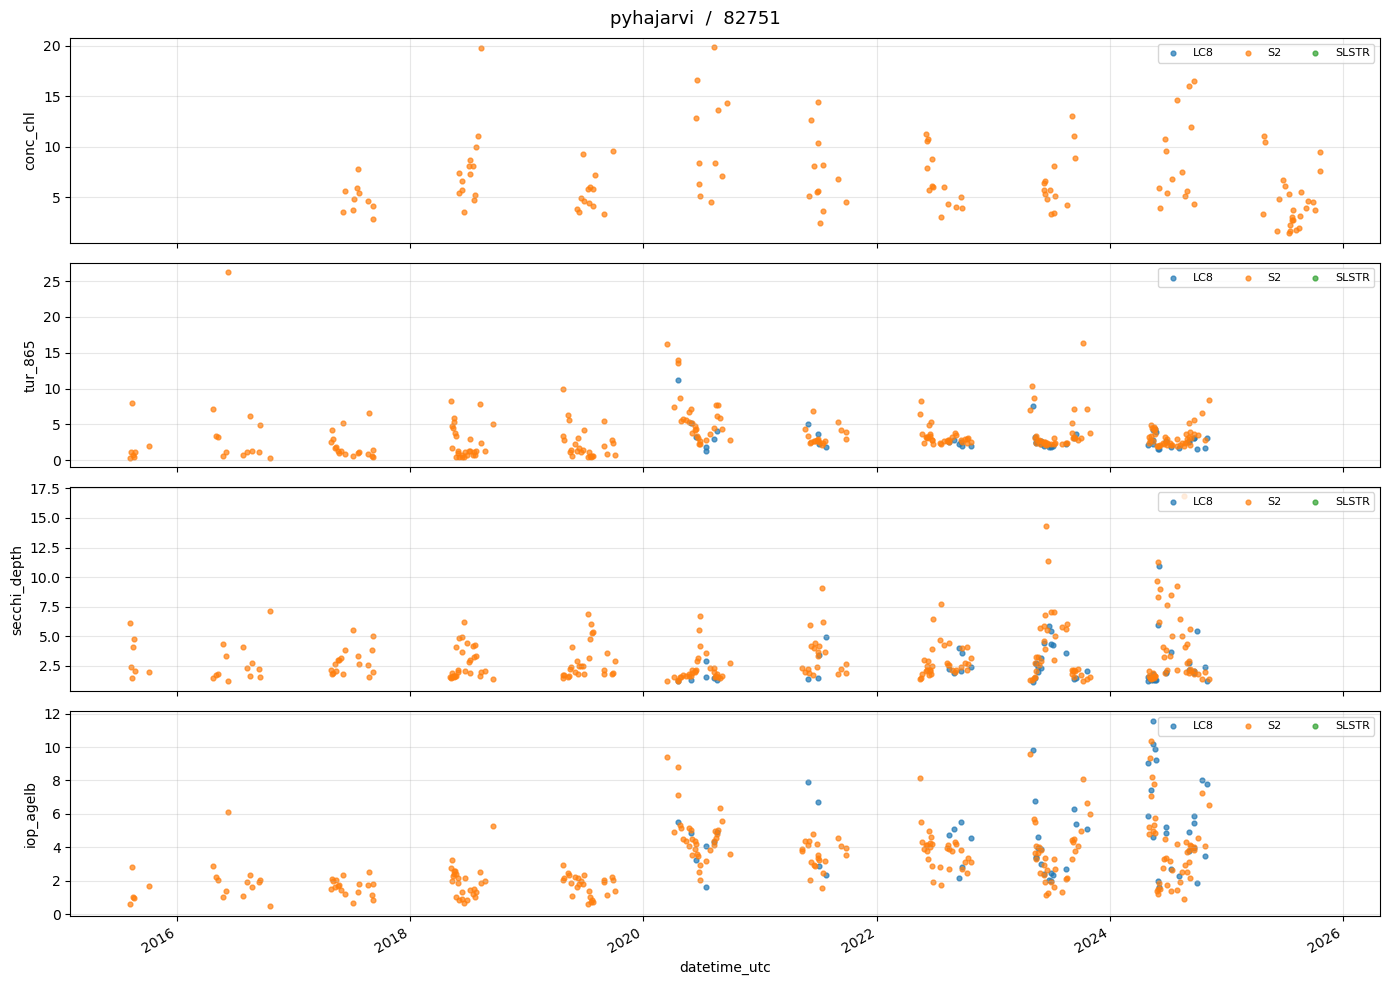

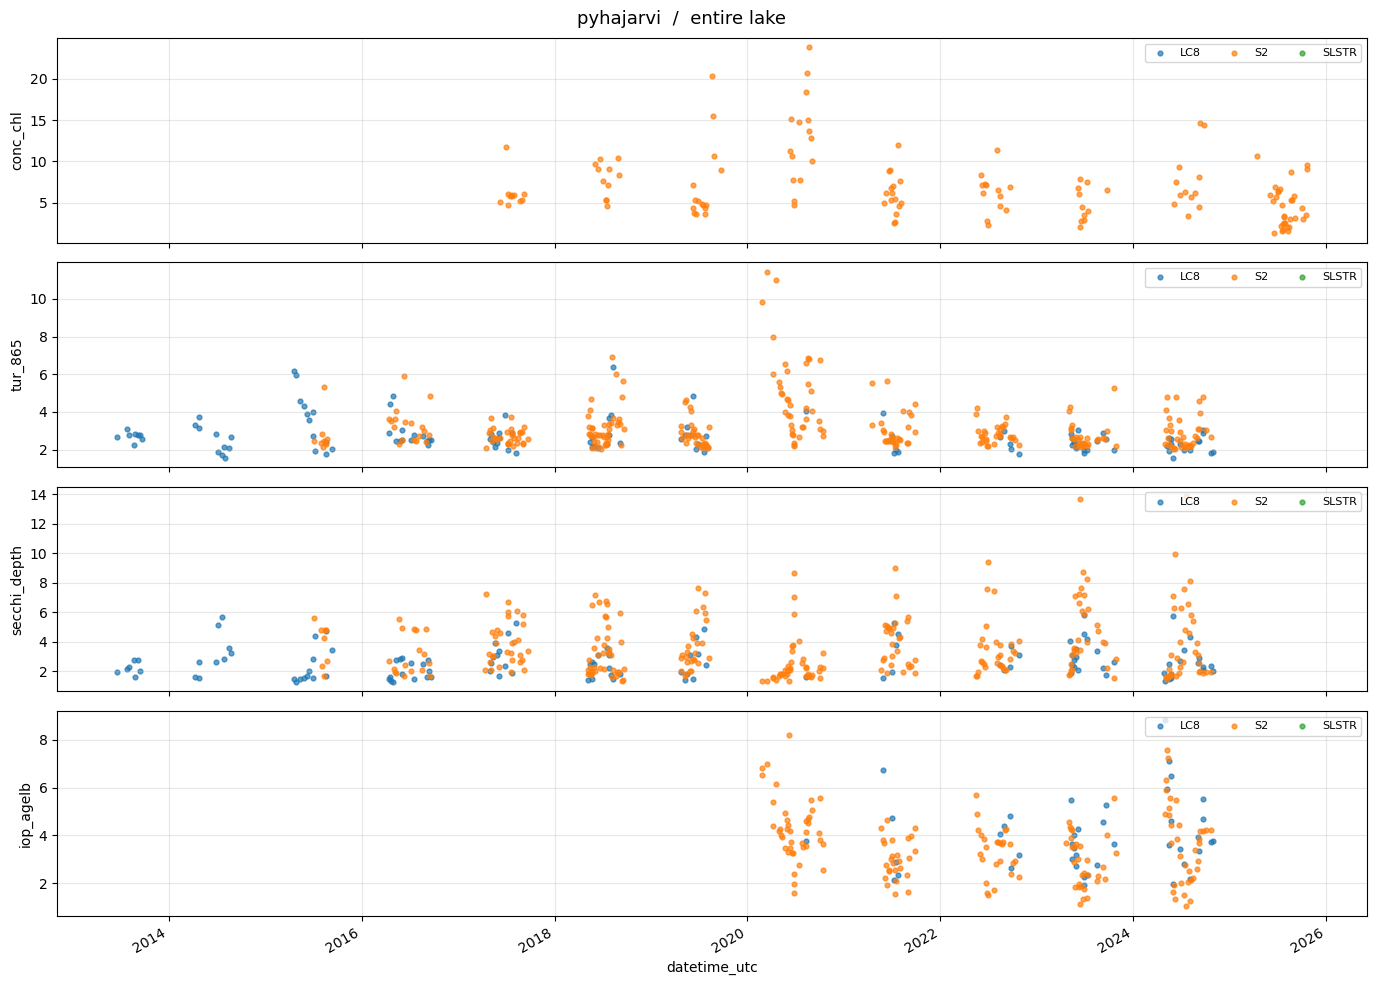

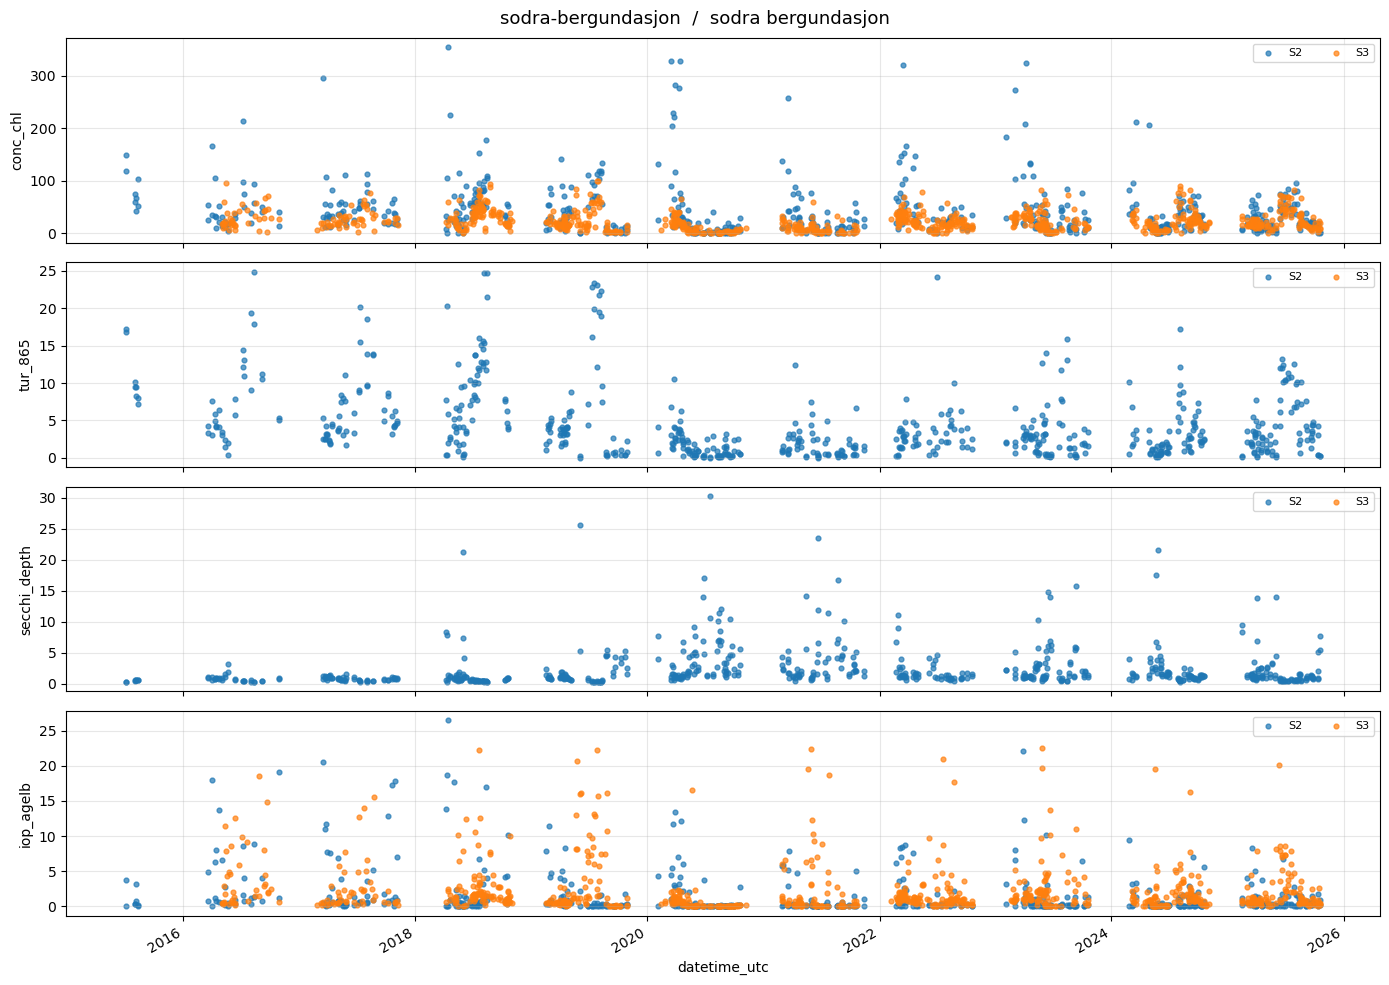

In [16]:
import matplotlib.pyplot as plt

EO_KEY_COLS = ["conc_chl", "tur_865", "secchi_depth", "iop_agelb"]

groups = eo_data_harmonized.groupby(["region", "site"], dropna=False)

for (region, site), group in groups:
    fig, axes = plt.subplots(len(EO_KEY_COLS), 1, figsize=(14, 10), sharex=True)
    site_label = site if pd.notna(site) else "—"
    fig.suptitle(f"{region}  /  {site_label}", fontsize=13)

    for ax, col in zip(axes, EO_KEY_COLS):
        for system, sys_group in group.groupby("system"):
            sys_group_sorted = sys_group.sort_values("datetime_utc")
            ax.scatter(
                sys_group_sorted["datetime_utc"],
                sys_group_sorted[col],
                label=system,
                s=12,
                alpha=0.7,
            )
        ax.set_ylabel(col)
        ax.legend(fontsize=8, loc="upper right", ncol=4)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("datetime_utc")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()